In [2]:
'''
K Nearest Neighbors
-----------------------
- Both Classification and Regression
- Classification -> KNeighborsClassifier
- Regression -> KNeighborsRegressor

- Classification
    - Calculate distance between data points to choose nearest neighbors to identify new data belongs to which class.

- Regression
    - Calculate distance between data points to get average data as a prediction value.

Finding optimal number of neighbors - Using Elbow Method Figure
-------------------------------------------------------------------
1. Error Rate
    - Maximum drop point of figure.
    
2. Accuracy Score
    - Highest Peak Point of figure.

Calculation of Elbow Method
-----------------------------
- Error Rate
    -> Number of wrong predictions

- Accuracy Score
    -> Accuracy of each execution of model.

k_range = range(1, 21) # 1 - 20
error_rate = []
acc_score = []

for i in k_range:
    knn = KNeighborsClassifier()
    knn.fit(X_train_scale, Y_train)
    knn_pred = knn.predict(X_test_scale)
    
    error_rate.append(np.mean(Y_test != knn_pred)) -> number of wrong prediction / total number of Y_test data
    acc_score.append(Y_test, knn_pred)

1000 Records -> population

Train -> 800
Test -> 200

emp_satis, emp_position, department    Knn_pred_label    Acc
1.5           A            CC              CC            0.85
3.5           B            ZZ              ZZ            0.43
4.6           D            yy              YY            0.75

Cross Validation
---------------------
- StratifiyFold
- cross_val_score

Overfitting and Underfitting
--------------------------------
Overfit -> when model learn more outliers data than important data
underfit -> when model learn all data but does not learn similar group data.

- Grid Search CV
- Random Search CV
'''

'\nK Nearest Neighbors\n-----------------------\n- Both Classification and Regression\n- Classification -> KNeighborsClassifier\n- Regression -> KNeighborsRegressor\n\n- Classification\n    - Calculate distance between data points to choose nearest neighbors to identify new data belongs to which class.\n\n- Regression\n    - Calculate distance between data points to get average data as a prediction value.\n\nFinding optimal number of neighbors - Using Elbow Method Figure\n-------------------------------------------------------------------\n1. Error Rate\n    - Maximum drop point of figure.\n\n2. Accuracy Score\n    - Highest Peak Point of figure.\n\nCalculation of Elbow Method\n-----------------------------\n- Error Rate\n    -> Number of wrong predictions\n\n- Accuracy Score\n    -> Accuracy of each execution of model.\n\nk_range = range(1, 21) # 1 - 20\nerror_rate = []\nacc_score = []\n\nfor i in k_range:\n    knn = KNeighborsClassifier()\n    knn.fit(X_train_scale, Y_train)\n    knn

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import KNN Model
# For KNN Regression -> KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
# Train Test Package
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
# Data Preprocessing Package
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Model metrics Package
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
df = pd.read_csv('dataset/student.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,very good,medium,high,very low,very low,good,6,5,6,6
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,excellent,medium,medium,very low,very low,good,4,5,5,6
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,very good,medium,low,low,medium,good,10,7,8,10
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,good,low,low,very low,very low,excellent,2,15,14,15
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,very good,medium,low,very low,low,excellent,4,6,10,10


In [5]:
# Change grade to label
df['G3'].sort_values(ascending=False).unique()

array([20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,  6,  5,  4,
        0])

In [6]:
def convertGrade(grade):
    if grade >= 15:
        return 'A'
    elif grade >= 11:
        return 'B'
    elif grade >= 7:
        return 'C'
    else:
        return 'D'

In [7]:
df['Grade'] = df['G3'].apply(convertGrade)

In [8]:
df['Grade'].value_counts()

Grade
B    136
C    125
A     73
D     61
Name: count, dtype: int64

In [9]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Grade'],
      dtype='str')

In [10]:
columns = df[['Medu', 'Fedu', 'traveltime', 'studytime', 'famrel', 'freetime', 
              'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Grade']]

columns_to_encode = ['famsup', 'schoolsup', 'internet']

# columns

# df['health'].unique()

## Label Encoding

In [11]:
'''
1. fit_transform() -> convert values to 0, 1, 2, 3, ..., n
2. inverse_transform() -> convert converted number back to label data.
    data = encoder.inverse_transform(df['failures_id'])
    data
'''
encoder = LabelEncoder()

for col in columns_to_encode:
    df[f'{col}_id'] = encoder.fit_transform(df[col])
print('Data converted...')

Data converted...


## Function to Manual Encode

In [12]:
def encodeData(dataframe, col_name, *args):
    encode_data = {}
    for idx, val in enumerate(args):
        encode_data[val] = idx

    dataframe[f'{col_name}_id'] = dataframe[col_name].map(encode_data)
    print(f'{col_name} data encoded...')

In [13]:
df['health'].unique()

<StringArray>
['good', 'excellent', 'very bad', 'bad', 'very good']
Length: 5, dtype: str

In [14]:
encodeData(df, 'Medu', 'none', 'primary education (4th grade)', '5th to 9th grade', 'secondary education', 'higher education')

Medu data encoded...


In [15]:
encodeData(df, 'Fedu', 'none', 'primary education (4th grade)', '5th to 9th grade', 'secondary education', 'higher education')

Fedu data encoded...


In [16]:
encodeData(df, 'traveltime', '<15 min.', '15 to 30 min.', '30 min. to 1 hour', '>1 hour')

traveltime data encoded...


In [17]:
encodeData(df, 'studytime', '<2 hours', '2 to 5 hours', '5 to 10 hours', '>10 hours')

studytime data encoded...


In [18]:
encodeData(df, 'famrel', 'very bad', 'bad', 'good', 'very good', 'excellent')

famrel data encoded...


In [19]:
encodeData(df, 'Grade', 'D', 'C', 'B', 'A')

Grade data encoded...


In [20]:
encodeData(df, 'health', 'very bad', 'bad', 'good', 'very good', 'excellent')

health data encoded...


In [21]:
cols = ['freetime', 'goout', 'Dalc', 'Walc']
for col in cols:
    encodeData(df, col, 'very low', 'low', 'medium', 'high', 'very high')

freetime data encoded...
goout data encoded...
Dalc data encoded...
Walc data encoded...


In [22]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Grade', 'famsup_id',
       'schoolsup_id', 'internet_id', 'Medu_id', 'Fedu_id', 'traveltime_id',
       'studytime_id', 'famrel_id', 'Grade_id', 'health_id', 'freetime_id',
       'goout_id', 'Dalc_id', 'Walc_id'],
      dtype='str')

#### Feature and Target

In [23]:
feature = ['Medu_id', 'Fedu_id', 'traveltime_id', 'studytime_id', 'famrel_id', 'famsup_id',
       'schoolsup_id', 'internet_id', 'freetime_id', 'goout_id', 'Dalc_id', 'Walc_id', 'failures',
          'health_id', 'absences', 'G1', 'G2']
target = 'Grade_id'

In [24]:
X = df[feature]
Y = df[target]

#### Train and Test

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

#### Feature Scaling

In [26]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

#### Elbow Method

In [27]:
k_range = range(1, 21)
error_rate = []
acc_score = []

for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scale, Y_train)
    knn_pred = knn.predict(X_test_scale)
    error_rate.append(np.mean(Y_test != knn_pred))
    acc_score.append(accuracy_score(Y_test, knn_pred))

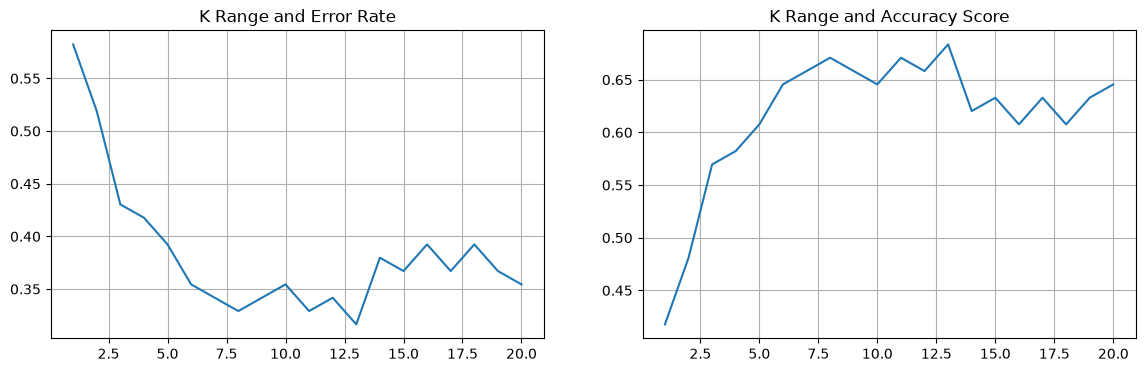

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax1 = axes[0]
ax1.plot(k_range, error_rate)
ax1.set_title('K Range and Error Rate')
ax1.grid()

ax2 = axes[1]
ax2.plot(k_range, acc_score)
ax2.set_title('K Range and Accuracy Score')
ax2.grid()

#### Model Implementation

In [29]:
# Optimal Neighbour Point
k = 13

# Model
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train_scale, Y_train)
Y_pred = model.predict(X_test_scale)

#### Model Metrics

In [30]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [31]:
print(cr)

              precision    recall  f1-score   support

           0       0.67      0.33      0.44        12
           1       0.63      0.76      0.69        25
           2       0.68      0.85      0.75        27
           3       0.89      0.53      0.67        15

    accuracy                           0.68        79
   macro avg       0.72      0.62      0.64        79
weighted avg       0.70      0.68      0.67        79



In [32]:
print(cm)

[[ 4  8  0  0]
 [ 2 19  4  0]
 [ 0  3 23  1]
 [ 0  0  7  8]]


### Cross Validation

In [33]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_error_rate = []
cv_acc_score = []


for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    scores = cross_val_score(knn, X_train_scale, Y_train, cv=kfold, scoring='accuracy')

    cv_acc_score.append(scores.mean())
    cv_error_rate.append(1 - scores.mean())

best_k = k_range[np.argmax(cv_acc_score)]
print(best_k)

8


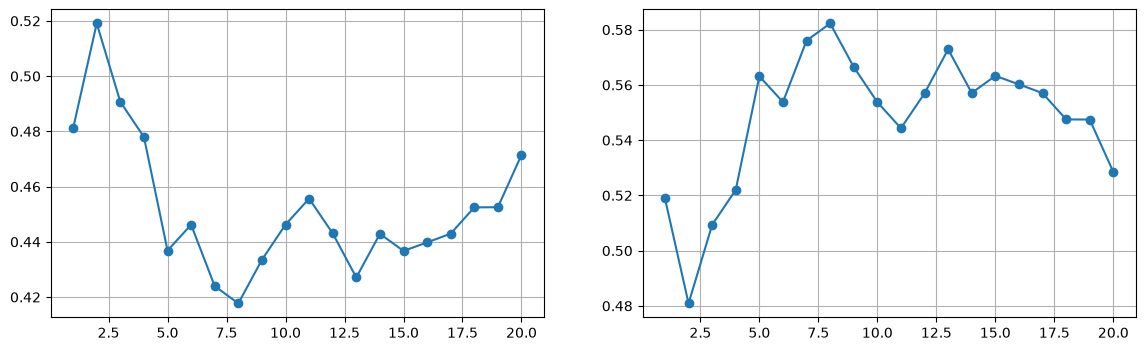

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax1 = axes[0]
ax1.plot(k_range, cv_error_rate, marker='o')
ax1.grid()

ax2 = axes[1]
ax2.plot(k_range, cv_acc_score, marker='o')
ax2.grid()

## Grid Search CV

In [35]:
'''
- euclidean -> continuous data + dense data
- manhattan -> Ordinal Data
- euclidean + manhattan -> nominal data
'''
param = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [36]:
grid_cv = GridSearchCV(
    estimator = KNeighborsClassifier(),
    param_grid = param,
    cv = kfold,
    scoring='accuracy',
    # use 1 core of cpu
    n_jobs = 1
)

In [37]:
grid_cv.fit(X_train_scale, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [1, 2, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"v

In [ ]:
best_knn = grid_cv.best_estimator_
best_knn_pred = best_knn.predict(X_test_scale)

KNeighborsClassifier(metric='manhattan', n_neighbors=12, weights='distance')


In [39]:
best_cm = confusion_matrix(Y_test, best_knn_pred)
best_cr = classification_report(Y_test, best_knn_pred)

In [40]:
print(best_cm)
print('\n')
print(best_cr)

[[ 5  6  1  0]
 [ 1 17  7  0]
 [ 0  2 24  1]
 [ 0  0  4 11]]


              precision    recall  f1-score   support

           0       0.83      0.42      0.56        12
           1       0.68      0.68      0.68        25
           2       0.67      0.89      0.76        27
           3       0.92      0.73      0.81        15

    accuracy                           0.72        79
   macro avg       0.77      0.68      0.70        79
weighted avg       0.74      0.72      0.71        79

